In [4]:
import numpy as np
import matplotlib.pyplot as plt

from set_eval.set_evaluators import TabularSetEval, FactoredSetEval, expectile, expectile_fit, quantile_fit
from set_eval.dataset_builder import RandomDataset, multimodal, pairwise

In [5]:
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

num_agents = 6
num_actions = 6
num_train = int(num_actions ** num_agents * .2)
num_test  = int(num_actions ** num_agents * .8)
num_sets  = 250   # query sets per set size

randoms = {
    "uniform on (-10, 10)": lambda size: 20 * np.random.random(size) - 10,
    "bimodal at -5, 5 (spread .1)": multimodal(peaks=[-5, 5], spread=.1),
    "half additive, half pairwise": pairwise(.5),
    "pairwise only": pairwise(1.0),
}
models = {
    "tabular / mean": (TabularSetEval, {"fill": np.mean}),
    "tabular / max": (TabularSetEval, {"fill": np.max}),
    "tabular / quantile .99": (TabularSetEval, {"fill": lambda x: np.quantile(x, .99)}),
    "tabular / expectile .99": (TabularSetEval, {"fill": expectile(.99)}),
    "factored / mean": (FactoredSetEval, {}),
    "factored / quantile .99": (FactoredSetEval, {"fit": quantile_fit(.99)}),
    "factored / expectile .99": (FactoredSetEval, {"fit": expectile_fit(.99)}),
}


def run_distribution(dist_name, seed):
    """Score every model on one distribution: build the value table and one
    train/test split, shared across the models so they are compared on
    identical queries. Runs in a worker process; only the small error dicts
    cross back to the parent (the big test-set arrays stay in the worker).
    """
    # forked workers inherit the parent's RNG state -- reseed so they differ
    np.random.seed(seed)
    dataset = RandomDataset(num_agents, num_actions, randoms[dist_name])
    train_points, test_sets = dataset.train_test_split(num_train, num_test, num_sets)
    result = {}
    for model_name, (cls, kwargs) in models.items():
        model = cls(num_agents, num_actions)
        model.learn(train_points, **kwargs)
        result[model_name] = {
            size: dataset.error(model.predict(sets), sets, lambda x, y: (x - y) ** 2).mean()
            for size, sets in test_sets.items()
        }
    return dist_name, result


# errors[distribution][model][set size] = MSE of the predicted set-max.
# fork (not spawn) so workers see the notebook-defined functions and dicts.
with ProcessPoolExecutor(max_workers=len(randoms), mp_context=mp.get_context("fork")) as pool:
    errors = dict(pool.map(run_distribution, randoms, range(len(randoms))))

set_sizes = list(next(iter(errors.values()))["tabular / mean"])
set_sizes

[1, 3, 10, 33, 107, 346, 1116, 3597, 11587, 37324]

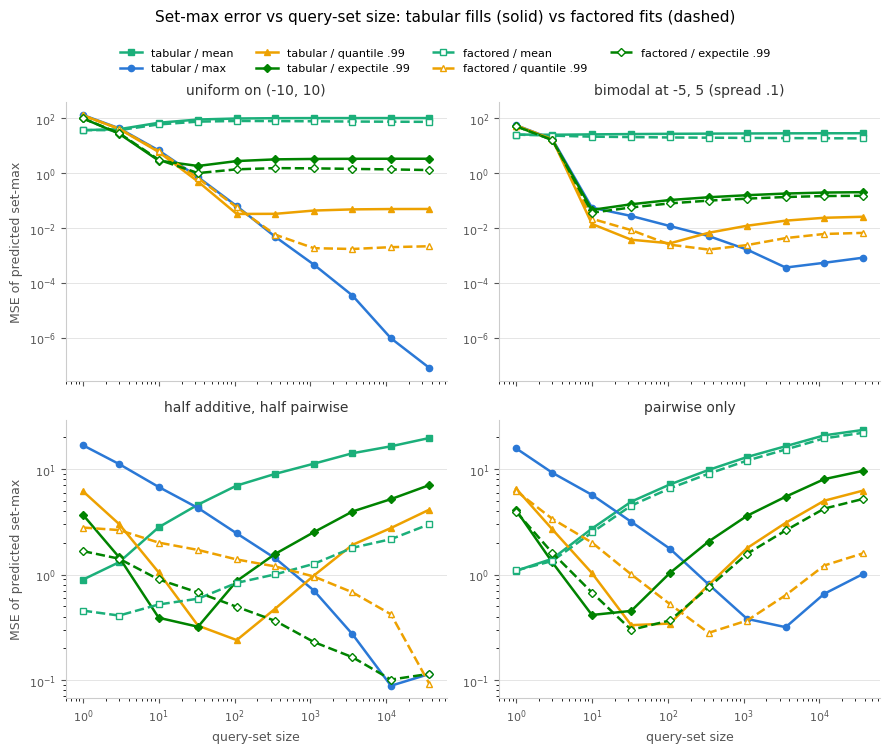

In [6]:
# Error vs query-set size, one panel per distribution. Color identifies the
# statistic, line style the model family (tabular solid, factored dashed).
# Log-log: sizes and errors both span orders of magnitude.
import math

colors  = {"mean": "#1baf7a", "max": "#2a78d6", "quantile .99": "#eda100", "expectile .99": "#008300"}
markers = {"mean": "s", "max": "o", "quantile .99": "^", "expectile .99": "D"}

def style(model_name):
    family, stat = model_name.split(" / ")
    dashed = family == "factored"
    return dict(color=colors[stat], marker=markers[stat], markersize=4.5,
                linestyle="--" if dashed else "-", linewidth=1.8,
                markerfacecolor="white" if dashed else None)

ncols = 2 if len(errors) <= 4 else 3
nrows = math.ceil(len(errors) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.6 * nrows),
                         sharex=True, sharey=False, squeeze=False)
for ax in axes.flat[len(errors):]:
    ax.set_visible(False)

for ax, (dist_name, by_model) in zip(axes.flat, errors.items()):
    for model_name, by_size in by_model.items():
        sizes = sorted(by_size)
        ax.plot(sizes, [by_size[s] for s in sizes], label=model_name, **style(model_name))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(dist_name, fontsize=10, color="#333333")
    ax.grid(True, which="major", axis="y", color="#e5e5e5", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=8, colors="#555555")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#cccccc")

# Each row shares its own y scale, independent of the other rows -- the
# structured distributions (pairwise-mix panels) have much smaller errors and
# would otherwise get compressed into a thin strip by the unstructured ones.
for row in axes:
    visible = [ax for ax in row if ax.get_visible()]
    if not visible:
        continue
    lo = min(ax.get_ylim()[0] for ax in visible)
    hi = max(ax.get_ylim()[1] for ax in visible)
    for ax in visible:
        ax.set_ylim(lo, hi)

for idx in range(len(errors)):
    if idx + ncols >= len(errors):   # no visible panel below this one
        axes.flat[idx].set_xlabel("query-set size", fontsize=9, color="#555555")
for ax in axes[:, 0]:
    ax.set_ylabel("MSE of predicted set-max", fontsize=9, color="#555555")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Set-max error vs query-set size: tabular fills (solid) vs factored fits (dashed)",
             fontsize=11, y=1.04)
plt.tight_layout()
plt.show()